<a href="https://colab.research.google.com/github/rks746/MIT_15.773_Hands_On_Deep_Learning_Spring_2024/blob/main/heart_disease_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
keras.utils.set_random_seed(42) # to shuffle it once and then keep using it in batches

In [3]:
df = pd.read_csv("https://storage.googleapis.com/download.tensorflow.org/data/heart.csv")

In [4]:
df.shape

(303, 14)

In [5]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,fixed,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,normal,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,reversible,0
3,37,1,3,130,250,0,0,187,0,3.5,3,0,normal,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,normal,0


In [6]:
df.target.value_counts(normalize=True, dropna=False) # to check if the dataset is balanced or not

,proportion
target,
0,0.726073
1,0.273927


In [7]:
# dataset is imbalanced
# since there are 72% zeroes in the classification, any fancy model should be atleast better than 72% since randomly predicting 0 (naive baseline model) would be right 72% of the times

In [8]:
# dividing the dataset into categorical and numeric variables
categorical_variables = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'ca', 'thal']
numeric_variables = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'slope']

In [9]:
df = pd.get_dummies(df, columns = categorical_variables, dtype = int) # this one-hot encodes the categorical vectors

In [10]:
df.head()

,age,trestbps,chol,thalach,oldpeak,slope,target,sex_0,sex_1,cp_0,...,exang_1,ca_0,ca_1,ca_2,ca_3,thal_1,thal_2,thal_fixed,thal_normal,thal_reversible
0,63,145,233,150,2.3,3,0,0,1,0,...,0,1,0,0,0,0,0,1,0,0
1,67,160,286,108,1.5,2,1,0,1,0,...,1,0,0,0,1,0,0,0,1,0
2,67,120,229,129,2.6,2,0,0,1,0,...,1,0,0,1,0,0,0,0,0,1
3,37,130,250,187,3.5,3,0,0,1,0,...,0,1,0,0,0,0,0,0,1,0
4,41,130,204,172,1.4,1,0,1,0,0,...,0,1,0,0,0,0,0,0,1,0


In [11]:
# splitting before standardization
test_df = df.sample(frac=0.2, random_state=42)
train_df = df.drop(test_df.index)

In [12]:
train_df.shape

(242, 30)

In [13]:
test_df.shape

(61, 30)

In [14]:
means = train_df[numeric_variables].mean()
sd = train_df[numeric_variables].std()

In [15]:
means

,0
age,54.268595
trestbps,131.995868
chol,246.512397
thalach,149.805785
oldpeak,1.032645
slope,1.590909


In [16]:
sd

,0
age,9.059861
trestbps,18.012789
chol,48.485377
thalach,23.132298
oldpeak,1.169729
slope,0.632783


In [17]:
# standardization
train_df[numeric_variables] = (train_df[numeric_variables] - means)/sd

In [18]:
test_df[numeric_variables] = (test_df[numeric_variables] - means)/sd

In [19]:
train_df.head()

,age,trestbps,chol,thalach,oldpeak,slope,target,sex_0,sex_1,cp_0,...,exang_1,ca_0,ca_1,ca_2,ca_3,thal_1,thal_2,thal_fixed,thal_normal,thal_reversible
0,0.963746,0.721939,-0.278690,0.008396,1.083461,2.226814,0,0,1,0,...,0,1,0,0,0,0,0,1,0,0
1,1.405254,1.554681,0.814423,-1.807247,0.399542,0.646494,1,0,1,0,...,1,0,0,0,1,0,0,0,1,0
2,1.405254,-0.665964,-0.361189,-0.899426,1.339930,0.646494,0,0,1,0,...,1,0,0,1,0,0,0,0,0,1
3,-1.906055,-0.110803,0.071931,1.607891,2.109339,2.226814,0,0,1,0,...,0,1,0,0,0,0,0,0,1,0
4,-1.464547,-0.110803,-0.876809,0.959447,0.314052,-0.933825,0,1,0,0,...,0,1,0,0,0,0,0,0,1,0


In [20]:
test_df.head()

,age,trestbps,chol,thalach,oldpeak,slope,target,sex_0,sex_1,cp_0,...,exang_1,ca_0,ca_1,ca_2,ca_3,thal_1,thal_2,thal_fixed,thal_normal,thal_reversible
179,-0.581532,-0.776996,-2.011171,-1.029115,-0.198888,-0.933825,0,0,1,0,...,0,0,0,0,1,0,0,0,1,0
228,0.080730,-0.221835,-0.856184,-0.856196,0.826991,0.646494,1,1,0,0,...,1,0,1,0,0,0,0,0,0,1
111,-0.029647,-1.221125,-0.670561,0.354233,0.485031,0.646494,0,1,0,0,...,0,1,0,0,0,0,0,0,1,0
246,0.301484,-0.110803,-0.216816,1.045906,-0.882807,0.646494,0,1,0,0,...,0,0,1,0,0,0,0,0,1,0
60,1.294877,-0.665964,1.144419,0.051625,-0.540847,0.646494,0,0,1,0,...,0,1,0,0,0,0,0,0,1,0


In [21]:
# converting dataframe to numpy
train = train_df.to_numpy()
test = test_df.to_numpy()

In [22]:
# seperating the dependant/target variable
train_X = np.delete(train, 6, axis=1)
test_X = np.delete(test, 6, axis=1)

In [23]:
train_X.shape, test_X.shape

((242, 29), (61, 29))

In [24]:
train_y = train[:, 6]
test_y = test[:, 6]

In [25]:
train_y.shape, test_y.shape

((242,), (61,))

In [26]:
# until here, it was preprocessing

In [27]:
# model building

num_columns = train_X.shape[1]

# define input layer
input_layer = keras.Input(shape = (num_columns,))

# feed the input layer to the hidden layer
h = keras.layers.Dense(16, activation = "relu", name = "Hidden")(input_layer)

# feed ouput of hidden layer to output layer
output_layer = keras.layers.Dense(1, activation = "sigmoid", name = "Output")(h)

# tell Keras that this input, output pair is your model
model = keras.Model(input_layer, output_layer)

In [28]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 29)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden (Dense)                  │ (None, 16)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 497 (1.94 KB)

 Trainable params: 497 (1.94 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# trainable parameters is 497
# let's verify
(29+1)*16 + (16+1)*1

497

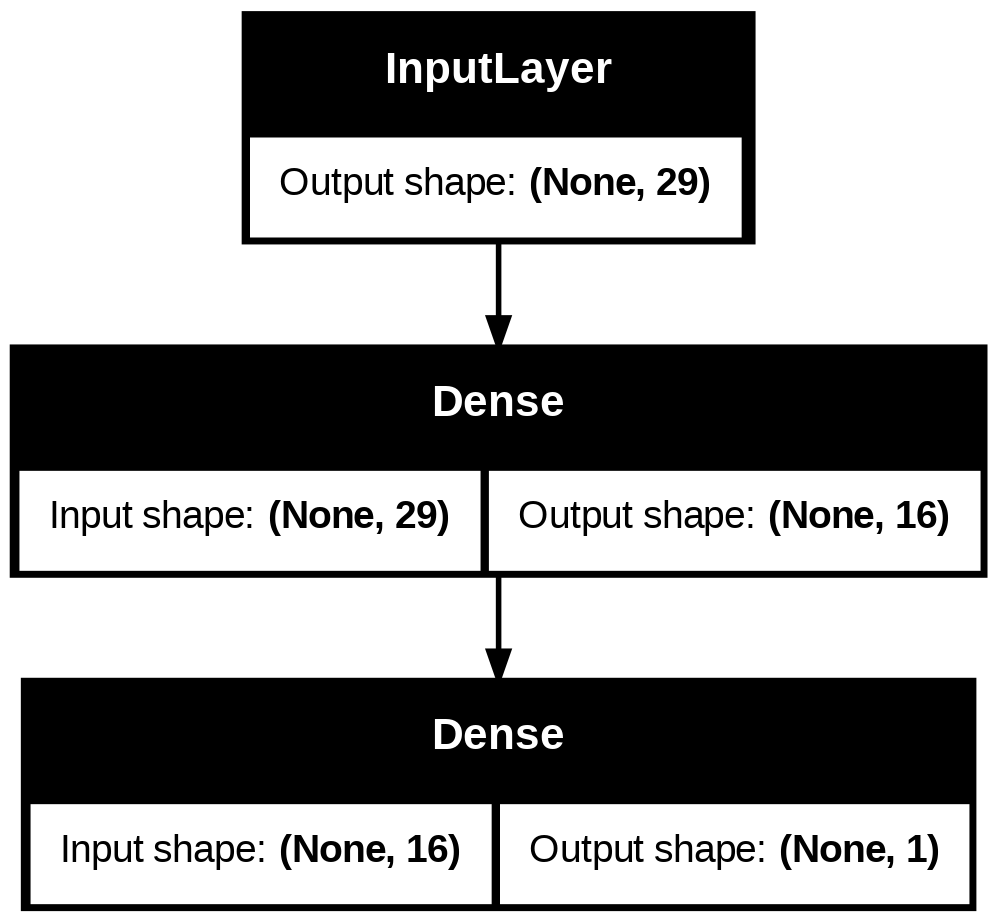

In [30]:
# visualizing the model
keras.utils.plot_model(model, show_shapes=True)

In [31]:
# loss function -> cross entropy
# optimizer -> Adam
# metric -> accuracy

In [32]:
# reorganizing the model to take care of parallel computing and distribution across server
model.compile (optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [33]:
history = model.fit(train_X, train_y, epochs=50, batch_size=32, verbose=1, validation_split=0.2)
# verbose = 1 means model gives a lot of descriptive output while training

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.5596 - loss: 0.7154 - val_accuracy: 0.5918 - val_loss: 0.6891
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6062 - loss: 0.6826 - val_accuracy: 0.6122 - val_loss: 0.6697
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6321 - loss: 0.6586 - val_accuracy: 0.6122 - val_loss: 0.6530
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6528 - loss: 0.6376 - val_accuracy: 0.6122 - val_loss: 0.6372
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6736 - loss: 0.6181 - val_accuracy: 0.6531 - val_loss: 0.6225
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6995 - loss: 0.5995 - val_accuracy: 0.6939 - val_loss: 0.6088
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7358 - loss: 0.5822 - val_accuracy: 0.6939 - val_loss: 0.5959
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7513 - loss: 0.5658 - val_accuracy: 0.7143 - val_loss: 0.5837


In [34]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

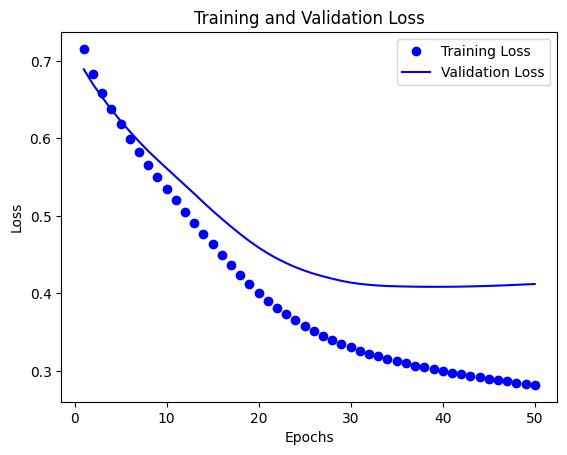

In [35]:
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range (1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "bo", label = "Training Loss")
plt.plot(epochs, val_loss_values, "b", label = "Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

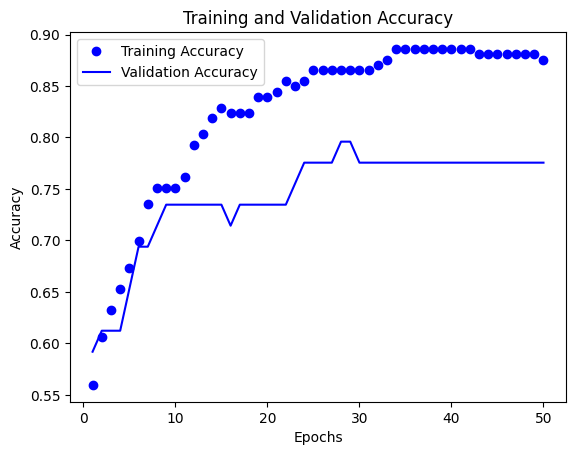

In [36]:
plt.clf()
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]
plt.plot(epochs, acc, "bo", label = "Training Accuracy")
plt.plot(epochs, val_acc, "b", label = "Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [37]:
model.evaluate(test_X, test_y)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8197 - loss: 0.3451


[0.3451109826564789, 0.8196721076965332]